In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../input/spaceship-titanic/train.csv")
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [5]:
df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [6]:
df.drop(df.columns[df.isnull().mean() > 0.7], axis =1, inplace = True)

In [7]:
df.shape

(8693, 14)

In [8]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
df.drop(columns = "PassengerId", inplace = True)

In [10]:
imp = SimpleImputer(missing_values= np.nan, strategy= "mean")
imp_trans =imp.fit_transform(df.select_dtypes("number"))

In [11]:
df_num= pd.DataFrame(imp_trans, columns = df.select_dtypes("number").columns)
df_num.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


In [12]:
imp_ob = SimpleImputer(strategy="most_frequent")
imp_transob =imp_ob.fit_transform(df.select_dtypes("object"))

In [13]:
df_imp_object = pd.DataFrame(imp_transob, columns = df.select_dtypes("object").columns)
df_imp_object.head()

,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
0,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy
1,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines
2,Europa,False,A/0/S,TRAPPIST-1e,True,Altark Susent
3,Europa,False,A/0/S,TRAPPIST-1e,False,Solam Susent
4,Earth,False,F/1/S,TRAPPIST-1e,False,Willy Santantines


In [14]:
df= pd.concat([df_num, df_imp_object, df.select_dtypes("bool")], axis =1)
df.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name,Transported
0,39.0,0.0,0.0,0.0,0.0,0.0,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy,False
1,24.0,109.0,9.0,25.0,549.0,44.0,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines,True
2,58.0,43.0,3576.0,0.0,6715.0,49.0,Europa,False,A/0/S,TRAPPIST-1e,True,Altark Susent,False
3,33.0,0.0,1283.0,371.0,3329.0,193.0,Europa,False,A/0/S,TRAPPIST-1e,False,Solam Susent,False
4,16.0,303.0,70.0,151.0,565.0,2.0,Earth,False,F/1/S,TRAPPIST-1e,False,Willy Santantines,True


In [15]:
df.isnull().sum()

Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
VIP             0
Name            0
Transported     0
dtype: int64

In [16]:
corr =df.select_dtypes("number").corr()

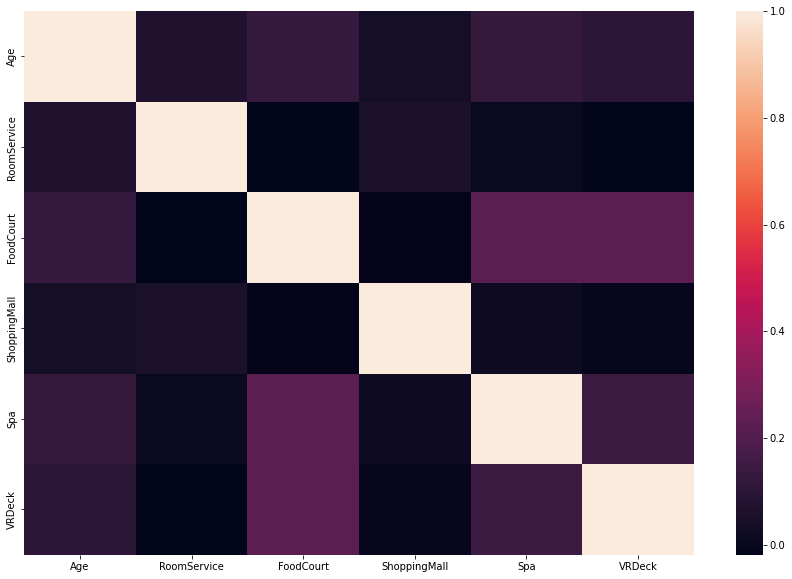

In [17]:
plt.figure(figsize=(15,10))
sns.heatmap(corr );

In [18]:
#There are high corr between ShoppingMall and Roomserverice,foodcourt,spa,vrdeck,
#which one should be stayed? the one that has high corr between "transported"

In [19]:
df["Transported"].corr(df["RoomService"])

-0.24204764964790834

In [20]:
df["Transported"].corr(df["Spa"])

-0.21879096278820717

In [21]:
df["Transported"].corr(df["VRDeck"])

-0.2048250787205457

In [22]:
df["Transported"].corr(df["FoodCourt"])

0.046074119381036956

In [23]:
df["Transported"].corr(df["ShoppingMall"])

0.010018967892669735

In [24]:
df.drop(columns = ["VRDeck","Spa","ShoppingMall","FoodCourt"], inplace = True )

In [25]:
df.shape

(8693, 9)

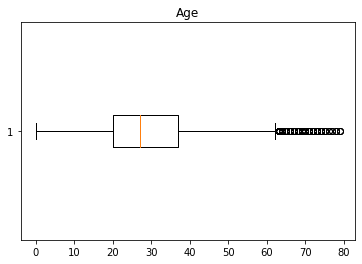

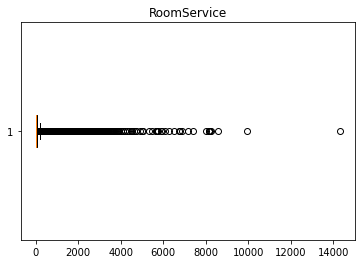

In [26]:
for i in df.select_dtypes("number").columns:
    
    plt.figure()
    plt.title(f'{i}')
    plt.boxplot(df[i], vert = False);

In [27]:
df = df[df["Age"] < 62]

In [28]:
df = df[df["RoomService"] < 2000]

In [29]:
df.head()

,Age,RoomService,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name,Transported
0,39.0,0.0,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy,False
1,24.0,109.0,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines,True
2,58.0,43.0,Europa,False,A/0/S,TRAPPIST-1e,True,Altark Susent,False
3,33.0,0.0,Europa,False,A/0/S,TRAPPIST-1e,False,Solam Susent,False
4,16.0,303.0,Earth,False,F/1/S,TRAPPIST-1e,False,Willy Santantines,True


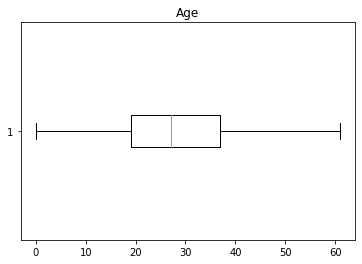

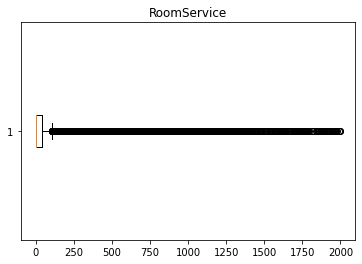

In [30]:
for i in df.select_dtypes("number").columns:
    
    plt.figure()
    plt.title(f'{i}')
    plt.boxplot(df[i], vert = False);

### df["Transported"].value_counts(normalize = True).plot(kind = "bar");

In [31]:
majority_class, minority_class = round(df["Transported"].value_counts(normalize = True),2)
print(majority_class, minority_class)

0.51 0.49


In [32]:
#split data

In [33]:
target = "Transported"
X= df.drop(columns = target)
y = df[target]

In [34]:
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size = 0.2, random_state = 42)

In [35]:
acc_baseline = y_train.value_counts(normalize = True).max()
print("Baseline Accuracy:", round(acc_baseline,2))

Baseline Accuracy: 0.52


In [36]:
model = make_pipeline( OneHotEncoder (use_cat_names = True), LogisticRegression(max_iter = 1000))
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['HomePlanet', 'CryoSleep', 'Cabin',
                                     'Destination', 'VIP', 'Name'],
                               use_cat_names=True)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [37]:
round(model.score(X_test, y_test), 2)

0.71

In [38]:
round(accuracy_score(y_train, model.predict(X_train)),2)

0.89

In [39]:
df_test = pd.read_csv("../input/spaceship-titanic/test.csv")
df_test.shape

(4277, 13)

In [40]:
df_test.drop(df_test.columns[df_test.isnull().mean() > 0.7], axis =1, inplace = True)

In [41]:
df_test.drop(columns = "PassengerId", inplace = True)

In [42]:
imp = SimpleImputer(missing_values= np.nan, strategy= "mean")
imp_trans =imp.fit_transform(df_test.select_dtypes("number"))

In [43]:
df_num= pd.DataFrame(imp_trans, columns = df_test.select_dtypes("number").columns)
df_num.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,27.0,0.0,0.0,0.0,0.0,0.0
1,19.0,0.0,9.0,0.0,2823.0,0.0
2,31.0,0.0,0.0,0.0,0.0,0.0
3,38.0,0.0,6652.0,0.0,181.0,585.0
4,20.0,10.0,0.0,635.0,0.0,0.0


In [44]:
imp_ob = SimpleImputer(strategy="most_frequent")
imp_transob =imp_ob.fit_transform(df_test.select_dtypes("object"))

In [45]:
df_imp_object = pd.DataFrame(imp_transob, columns = df_test.select_dtypes("object").columns)
df_imp_object.head()

,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
0,Earth,True,G/3/S,TRAPPIST-1e,False,Nelly Carsoning
1,Earth,False,F/4/S,TRAPPIST-1e,False,Lerome Peckers
2,Europa,True,C/0/S,55 Cancri e,False,Sabih Unhearfus
3,Europa,False,C/1/S,TRAPPIST-1e,False,Meratz Caltilter
4,Earth,False,F/5/S,TRAPPIST-1e,False,Brence Harperez


In [46]:
df_test= pd.concat([df_num, df_imp_object], axis =1)

In [47]:
df_test.drop(columns = ["VRDeck","Spa","ShoppingMall","FoodCourt"], inplace = True )

In [48]:
df_test.shape

(4277, 8)

In [49]:
y_pred = model.predict(df_test)
y_pred[:5]

array([ True, False,  True, False, False])

In [50]:
pred = pd.DataFrame(y_pred)
sub_df = pd.read_csv("../input/spaceship-titanic/sample_submission.csv")
datasets = pd.concat([sub_df["PassengerId"], pred], axis = 1)
datasets.columns = ["PassengerId", "Transported"]
datasets.to_csv("./titanic_space_comp_res", index = False)